In [93]:
# ============================================================
# LDS (Linear Datamodeling Score) Results Visualisation
# ============================================================

# ------------------------------------------------------------
# Cell 1: Imports
# ------------------------------------------------------------
import json
import os
import re
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [94]:
# ------------------------------------------------------------
# Cell 2: Global Matplotlib Style
# ------------------------------------------------------------
plt.rcParams.update(
    {
        "font.size": 12,
        "font.family": "STIXGeneral",
        "mathtext.fontset": "stix",
        "text.usetex": False,
        "axes.linewidth": 1.2,
        "grid.linewidth": 0.5,
        "lines.linewidth": 2,
        "legend.frameon": True,
        "legend.fancybox": False,
        "legend.edgecolor": "black",
        "legend.framealpha": 1.0,
    }
)
print("Style configured.")

Style configured.


In [95]:
# ------------------------------------------------------------
# Cell 3: Global Configuration
# ------------------------------------------------------------

# ── Path to your LDS results JSON ──────────────────────────
JSON_PATH = "/Users/jgsi/Downloads/20260415-130756.json"  #

# ── Output directory for saved figures ─────────────────────
FIGURES_DIR = "figures/lds"
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Methods to hide from all plots ─────────────────────────
EXCLUDE_METHODS: list[str] = []

# ── Colour palette ─────────────────────────────────────────
COLORS: dict[str, str] = {
    "exact": "#8c564b",  # brown  – oracle baseline
    "gnh": "#d62728",  # red
    "fim": "#2ca02c",  # green
    "block_fim": "#9467bd",  # purple
    "block_hessian": "#17becf",  # cyan
    "kfac": "#1f77b4",  # blue
    "ekfac": "#ff7f0e",  # orange
}

# ── Human-readable method labels ───────────────────────────
METHOD_LABELS: dict[str, str] = {
    "exact": "Exact",
    "gnh": "GNH",
    "fim": "FIM",
    "block_fim": "Block FIM",
    "block_hessian": "Block Hessian",
    "kfac": "K-FAC",
    "ekfac": "EK-FAC",
}

print("Configuration loaded.")

Configuration loaded.


In [96]:
# ------------------------------------------------------------
# Cell 4: Helper Functions
# ------------------------------------------------------------


def extract_layer_info(model_name: str) -> tuple[int, int]:
    """Return (num_layers, hidden_dim) from a model name like 'mlp_hidden[16, 16]'."""
    m = re.search(r"\[([^\]]+)\]", model_name)
    if m:
        dims = [int(x.strip()) for x in m.group(1).split(",")]
        return len(dims), dims[0]
    return 0, 0


def depth_label(model_name: str) -> str:
    """Human-readable architecture label."""
    n, h = extract_layer_info(model_name)
    return f"1 Layer\n(h={h})" if n == 1 else f"{n} Layers\n(h={h})"


def sort_models(names: list[str]) -> list[str]:
    return sorted(names, key=lambda n: extract_layer_info(n))


def organize(results: list[dict]) -> dict:
    """Returns {model_name: {epoch: result_dict}}."""
    out: dict = defaultdict(dict)
    for r in results:
        out[r["model_name"]][r.get("epoch")] = r
    return out


def active_methods(results: list[dict]) -> list[str]:
    """Return methods present in data, minus EXCLUDE_METHODS, in canonical order."""
    seen: set[str] = set()
    for r in results:
        seen.update(r["lds_scores"].keys())
    order = list(METHOD_LABELS.keys())  # canonical ordering
    return [m for m in order if m in seen and m not in EXCLUDE_METHODS]


def ci_from_result(score: dict) -> tuple[float, float]:
    """Return (err_low, err_high) for an error-bar relative to the mean."""
    mean = score["mean_lds"]
    if "ci_low" in score and "ci_high" in score:
        return mean - score["ci_low"], score["ci_high"] - mean
    std = score.get("std_lds", 0.0)
    return std, std


def save(fig: plt.Figure, name: str) -> None:
    path = os.path.join(FIGURES_DIR, name)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")


print("Helper functions defined.")

Helper functions defined.


In [97]:
# ------------------------------------------------------------
# Cell 5: Load Data
# ------------------------------------------------------------
with open(JSON_PATH) as f:
    data = json.load(f)

results = data["results"]
by_model = organize(results)
model_names = sort_models(list(by_model.keys()))
epochs_all = sorted({r.get("epoch") for r in results})
methods = active_methods(results)

print(f"Experiment : {data['experiment_name']}")
print(f"Timestamp  : {data['timestamp']}")
print(f"Models     : {len(model_names)}")
for mn in model_names:
    eps = sorted(by_model[mn].keys())
    n, h = extract_layer_info(mn)
    print(f"  {mn}  ({n} layer(s), h={h})  epochs={eps}")
print(f"Methods    : {methods}")
print(f"Epochs     : {epochs_all}")

Experiment : digits_lds
Timestamp  : 20260415-130756
Models     : 1
  linear_hiddenNone  (0 layer(s), h=0)  epochs=[10, 100, 1000]
Methods    : ['exact', 'gnh', 'fim', 'block_fim', 'block_hessian', 'kfac', 'ekfac']
Epochs     : [10, 100, 1000]


Saved: figures/lds/lds_per_epoch_bar.png


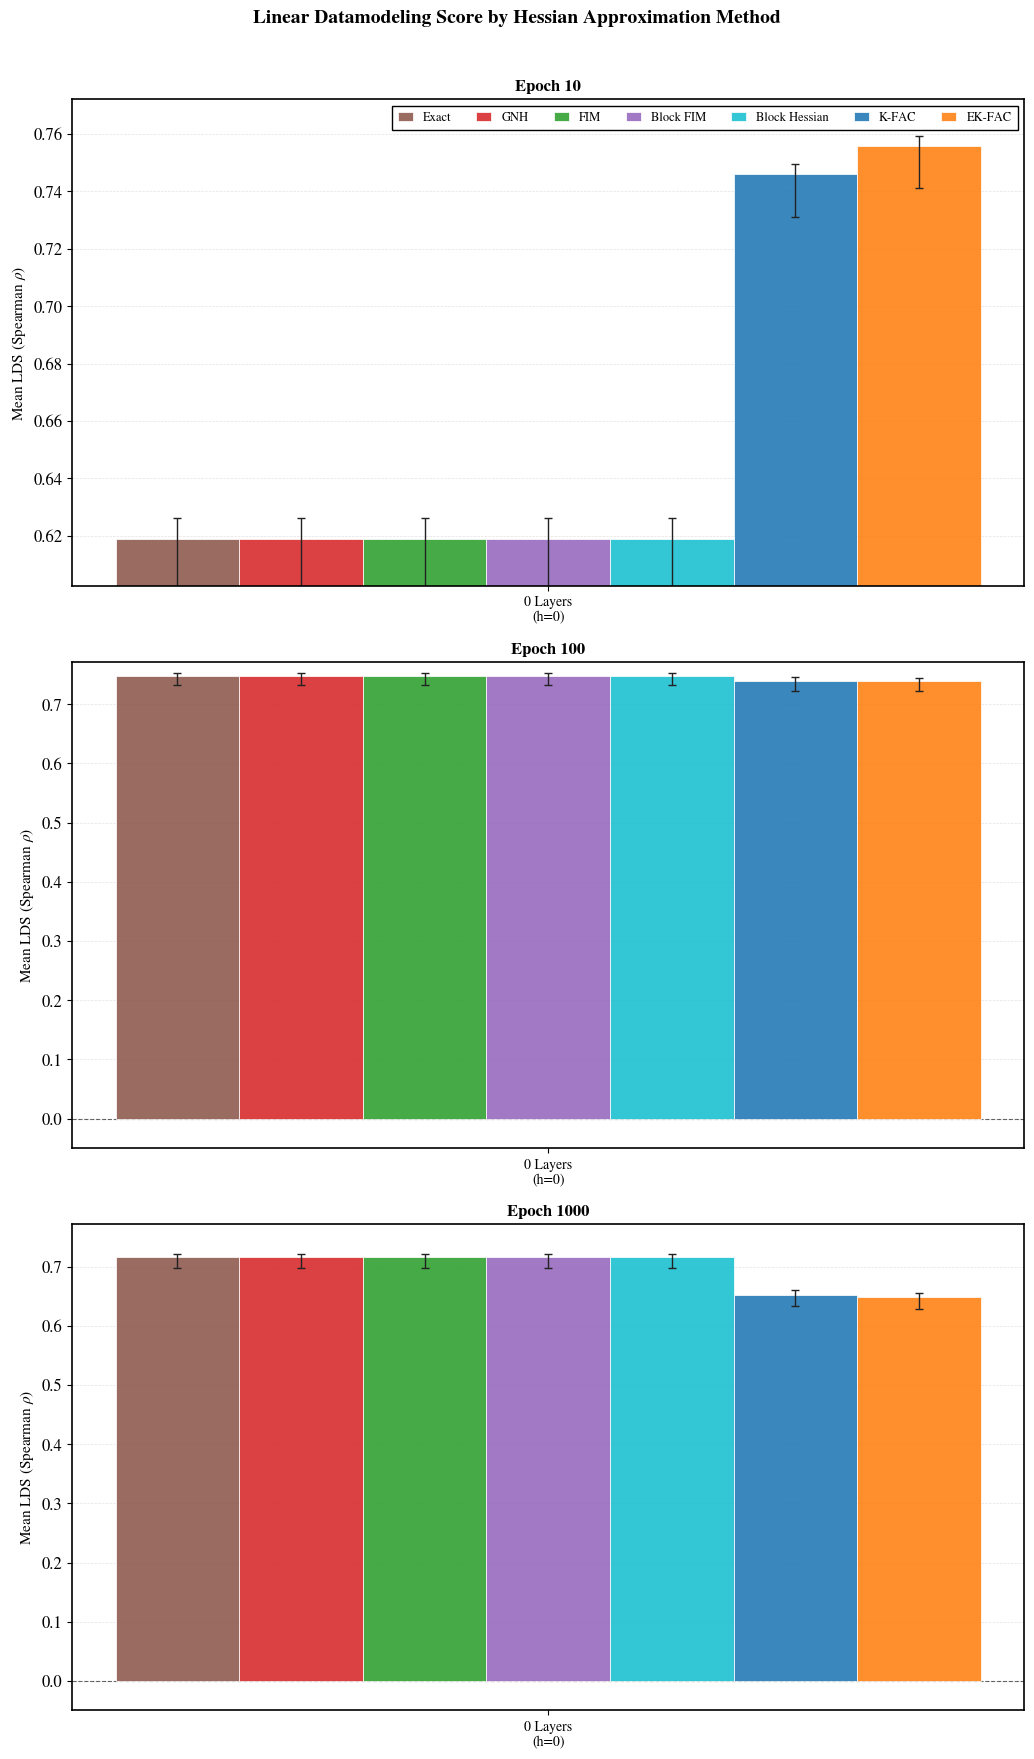

In [98]:
# ------------------------------------------------------------
# Cell 6: Plot 1 — LDS per Method, grouped by Architecture
#         One subplot per epoch.
# ------------------------------------------------------------

epochs_to_plot = [e for e in epochs_all if e is not None]
n_epochs = len(epochs_to_plot)
n_models = len(model_names)
n_methods = len(methods)

bar_w = 0.75 / n_methods
x_pos = np.arange(n_models)

fig, axes = plt.subplots(
    n_epochs,
    1,
    figsize=(max(8, 1.5 * n_models * n_methods), 4.2 * n_epochs),
    squeeze=False,
)

for row, epoch in enumerate(epochs_to_plot):
    ax = axes[row, 0]

    for mi, method in enumerate(methods):
        means = []
        err_lo = []
        err_hi = []
        for mn in model_names:
            score = by_model[mn].get(epoch, {}).get("lds_scores", {}).get(method, {})
            m = score.get("mean_lds", 0.0)
            lo, hi = ci_from_result(score) if score else (0.0, 0.0)
            means.append(m)
            err_lo.append(lo)
            err_hi.append(hi)

        offset = (mi - n_methods / 2 + 0.5) * bar_w
        color = COLORS.get(method, "#999")
        label = METHOD_LABELS.get(method, method)
        ax.bar(
            x_pos + offset,
            means,
            bar_w,
            label=label,
            color=color,
            alpha=0.88,
            edgecolor="white",
            linewidth=0.6,
        )
        ax.errorbar(
            x_pos + offset,
            means,
            yerr=[err_lo, err_hi],
            fmt="none",
            color="#222",
            capsize=3,
            linewidth=1.0,
            capthick=1.0,
        )

    ax.axhline(0, color="#555", linewidth=0.8, linestyle="--", zorder=0)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([depth_label(mn) for mn in model_names], fontsize=10)
    ax.set_ylabel("Mean LDS (Spearman $\\rho$)", fontsize=11)
    ax.set_title(f"Epoch {epoch}", fontweight="bold", fontsize=12)
    ax.set_ylim(bottom=min(-0.05, ax.get_ylim()[0]))
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)
    if row == 0:
        ax.legend(
            loc="upper right",
            ncol=n_methods,
            fontsize=9,
            handlelength=1.2,
            borderpad=0.5,
        )
        # Increase vertical space for each epoch panel
        fig.set_size_inches(fig.get_figwidth(), 5.8 * n_epochs, forward=True)

        # Use a tighter shared y-range so bars appear taller
        all_means = [
            by_model[mn]
            .get(ep, {})
            .get("lds_scores", {})
            .get(method, {})
            .get("mean_lds", np.nan)
            for ep in epochs_to_plot
            for mn in model_names
            for method in methods
        ]
        all_means = np.array(all_means, dtype=float)
        all_means = all_means[~np.isnan(all_means)]

        if all_means.size:
            y0, y1 = float(all_means.min()), float(all_means.max())
            pad = 0.12 * max(1e-6, (y1 - y0))
            for ax in axes[:, 0]:
                ax.set_ylim(y0 - pad, y1 + pad)
fig.suptitle(
    "Linear Datamodeling Score by Hessian Approximation Method",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
save(fig, "lds_per_epoch_bar.png")
plt.show()

Saved: figures/lds/lds_vs_epoch_lines.png


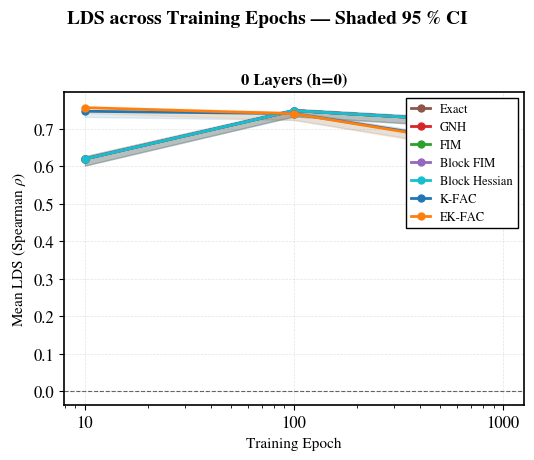

In [99]:
# ------------------------------------------------------------
# Cell 7: Plot 2 — LDS vs Training Epoch (Line Plots)
#         One panel per model architecture.
# ------------------------------------------------------------

if len(epochs_to_plot) < 2:
    print("Skipping epoch-development plot: fewer than 2 epochs in data.")
else:
    fig, axes = plt.subplots(
        1,
        n_models,
        figsize=(5.5 * n_models, 4.5),
        sharey=True,
        squeeze=False,
    )

    for col, mn in enumerate(model_names):
        ax = axes[0, col]

        for method in methods:
            xs, ys, lo_errs, hi_errs = [], [], [], []
            for epoch in epochs_to_plot:
                score = (
                    by_model[mn].get(epoch, {}).get("lds_scores", {}).get(method, {})
                )
                if not score:
                    continue
                xs.append(epoch)
                ys.append(score.get("mean_lds", 0.0))
                lo, hi = ci_from_result(score)
                lo_errs.append(lo)
                hi_errs.append(hi)

            if not xs:
                continue
            color = COLORS.get(method, "#999")
            label = METHOD_LABELS.get(method, method)
            ax.plot(xs, ys, marker="o", color=color, label=label, markersize=5)
            ax.fill_between(
                xs,
                [y - lo for y, lo in zip(ys, lo_errs)],
                [y + hi for y, hi in zip(ys, hi_errs)],
                color=color,
                alpha=0.12,
            )

        ax.axhline(0, color="#555", linewidth=0.8, linestyle="--", zorder=0)
        ax.set_xscale("log")
        ax.set_xticks(epochs_to_plot)
        ax.set_xticklabels([str(e) for e in epochs_to_plot])
        ax.set_xlabel("Training Epoch", fontsize=11)
        ax.set_title(depth_label(mn).replace("\n", " "), fontweight="bold", fontsize=12)
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.set_axisbelow(True)
        if col == 0:
            ax.set_ylabel("Mean LDS (Spearman $\\rho$)", fontsize=11)
        if col == n_models - 1:
            ax.legend(loc="upper right", fontsize=9, handlelength=1.5)

    fig.suptitle(
        "LDS across Training Epochs — Shaded 95 % CI",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    save(fig, "lds_vs_epoch_lines.png")
    plt.show()

Saved: figures/lds/lds_per_query_violin.png


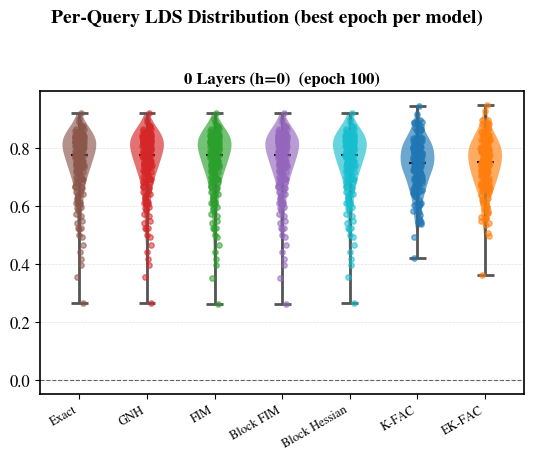

In [100]:
# ------------------------------------------------------------
# Cell 8: Plot 3 — Per-Query LDS Distribution (Violin)
#         Shows within-method variance across test queries.
#         Uses the epoch with the highest mean LDS (per model).
# ------------------------------------------------------------


def best_epoch_for_model(mn: str) -> int | None:
    """Epoch with the highest mean LDS summed across all methods."""
    best_ep, best_val = None, -1e9
    for ep, res in by_model[mn].items():
        total = sum(res["lds_scores"].get(m, {}).get("mean_lds", 0.0) for m in methods)
        if total > best_val:
            best_val, best_ep = total, ep
    return best_ep


fig, axes = plt.subplots(
    1,
    n_models,
    figsize=(5.5 * n_models, 4.5),
    sharey=True,
    squeeze=False,
)

for col, mn in enumerate(model_names):
    ax = axes[0, col]
    ep = best_epoch_for_model(mn)
    res = by_model[mn].get(ep, {})
    scores_by_method = res.get("lds_scores", {})

    violin_data = []
    violin_pos = []
    violin_cols = []
    violin_labels = []

    for mi, method in enumerate(methods):
        pq = scores_by_method.get(method, {}).get("per_query_lds", [])
        if not pq:
            continue
        violin_data.append(pq)
        violin_pos.append(mi)
        violin_cols.append(COLORS.get(method, "#999"))
        violin_labels.append(METHOD_LABELS.get(method, method))

    if violin_data:
        parts = ax.violinplot(
            violin_data,
            positions=violin_pos,
            showmedians=True,
            showextrema=True,
        )
        for body, col in zip(parts["bodies"], violin_cols):
            body.set_facecolor(col)
            body.set_alpha(0.65)
        parts["cmedians"].set_color("#111")
        parts["cmedians"].set_linewidth(1.5)
        parts["cbars"].set_color("#555")
        parts["cmaxes"].set_color("#555")
        parts["cmins"].set_color("#555")

        # Overlay individual query points
        for mi, pq in enumerate(violin_data):
            jitter = np.random.default_rng(42).uniform(-0.07, 0.07, len(pq))
            ax.scatter(
                [mi] * len(pq) + jitter,
                pq,
                color=violin_cols[mi],
                s=15,
                alpha=0.55,
                zorder=3,
            )

    ax.axhline(0, color="#555", linewidth=0.8, linestyle="--", zorder=0)
    ax.set_xticks(range(len(violin_labels)))
    ax.set_xticklabels(violin_labels, rotation=30, ha="right", fontsize=9)
    ax.set_title(
        f"{depth_label(mn).replace(chr(10), ' ')}  (epoch {ep})",
        fontweight="bold",
        fontsize=12,
    )
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)
    if col == 0:
        ax.set_ylabel("Per-Query LDS (Spearman $\\rho$)", fontsize=11)

fig.suptitle(
    "Per-Query LDS Distribution (best epoch per model)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
save(fig, "lds_per_query_violin.png")
plt.show()

Saved: figures/lds/lds_heatmap.png


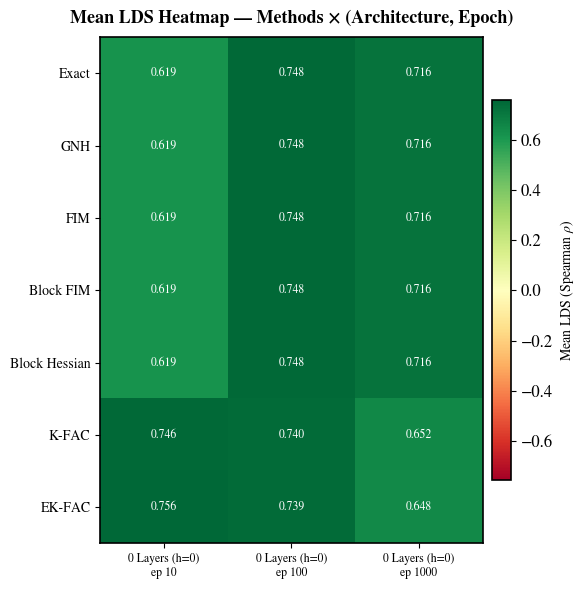

In [101]:
# ------------------------------------------------------------
# Cell 9: Plot 4 — Summary Heatmap
#         Rows = methods, Columns = (model, epoch) pairs.
# ------------------------------------------------------------

# Build column labels and collect values
col_labels: list[str] = []
matrix_data: list[list[float]] = [[] for _ in methods]

for mn in model_names:
    arch = depth_label(mn).replace("\n", " ")
    for epoch in epochs_to_plot:
        col_labels.append(f"{arch}\nep {epoch}")
        scores = by_model[mn].get(epoch, {}).get("lds_scores", {})
        for ri, method in enumerate(methods):
            matrix_data[ri].append(scores.get(method, {}).get("mean_lds", float("nan")))

Z = np.array(matrix_data)  # shape: (n_methods, n_cols)
row_labels = [METHOD_LABELS.get(m, m) for m in methods]

fig, ax = plt.subplots(figsize=(max(6, 1.3 * Z.shape[1]), 0.65 * Z.shape[0] + 1.5))

vabs = np.nanmax(np.abs(Z))
im = ax.imshow(Z, aspect="auto", cmap="RdYlGn", vmin=-vabs, vmax=vabs)

# Annotate cells
for ri in range(Z.shape[0]):
    for ci in range(Z.shape[1]):
        val = Z[ri, ci]
        if not np.isnan(val):
            text_col = "black" if abs(val) < 0.6 * vabs else "white"
            ax.text(
                ci,
                ri,
                f"{val:.3f}",
                ha="center",
                va="center",
                fontsize=8.5,
                color=text_col,
            )

# Column separator lines between models
n_ep = len(epochs_to_plot)
for mi in range(1, n_models):
    ax.axvline(mi * n_ep - 0.5, color="white", linewidth=2)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=8.5)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=10)
ax.set_title(
    "Mean LDS Heatmap — Methods × (Architecture, Epoch)",
    fontweight="bold",
    fontsize=13,
    pad=10,
)

cbar = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label("Mean LDS (Spearman $\\rho$)", fontsize=10)

plt.tight_layout()
save(fig, "lds_heatmap.png")
plt.show()

In [102]:
# ------------------------------------------------------------
# Cell 10: Numerical Summary Table
# ------------------------------------------------------------
print(
    f"{'Method':<16}"
    + "".join(
        f"{mn + ' ep=' + str(ep):>24}" for mn in model_names for ep in epochs_to_plot
    )
)
print("-" * (16 + 24 * len(model_names) * len(epochs_to_plot)))

for method in methods:
    row = f"{METHOD_LABELS.get(method, method):<16}"
    for mn in model_names:
        for epoch in epochs_to_plot:
            score = by_model[mn].get(epoch, {}).get("lds_scores", {}).get(method, {})
            mean = score.get("mean_lds", float("nan"))
            std = score.get("std_lds", float("nan"))
            row += f"{mean:>10.4f} ± {std:<10.4f}"
    print(row)

print(f"\nFigures written to: {os.path.abspath(FIGURES_DIR)}/")

Method           linear_hiddenNone ep=10linear_hiddenNone ep=100linear_hiddenNone ep=1000
----------------------------------------------------------------------------------------
Exact               0.6189 ± 0.1128        0.7478 ± 0.1109        0.7156 ± 0.1489    
GNH                 0.6189 ± 0.1128        0.7478 ± 0.1109        0.7156 ± 0.1489    
FIM                 0.6189 ± 0.1128        0.7478 ± 0.1109        0.7156 ± 0.1490    
Block FIM           0.6189 ± 0.1128        0.7478 ± 0.1109        0.7156 ± 0.1490    
Block Hessian       0.6189 ± 0.1128        0.7478 ± 0.1109        0.7156 ± 0.1489    
K-FAC               0.7461 ± 0.0914        0.7398 ± 0.0890        0.6517 ± 0.1400    
EK-FAC              0.7557 ± 0.0871        0.7395 ± 0.0924        0.6481 ± 0.1402    

Figures written to: /Users/jgsi/Local Documents/Influence Functions/Hessian Approximation/figures/lds/
